<img src = "BITS_university_logo.gif">

<h1><center>Work Integrated Learning Programmes Division<br>
M.Tech (Data Science and Engineering)<br> Data Visualization And Interpretation<br>
</center></h1>

<h2><center>Assignment 2 – PS5 [Weightage 13%]</center></h2>

<style>
table {
  font-family: arial, sans-serif;
  border-collapse: collapse;
  width: 100%;
}

td, th {
  border: 1px solid #dddddd;
  text-align: left;
  padding: 8px;
}

tr:nth-child(even) {
  background-color: #dddddd;
}
</style>

<h2>Group No: 30</h2>

<table>
  <tr>
    <th>Full Name</th>
    <th>BITS ID</th>
  </tr>
  <tr>
    <td>R BALAJI</td>
    <td>2021C104109</td>
  </tr>
  <tr>
    <td>MUTHURAJA M</td>
    <td>2021C104112</td>
  </tr>
  <tr>
    <td>DIVYA SUSAN KURIAN</td>
    <td>2021C104120</td>
  </tr>  
</table>

<h2>Objective</h2>
<h4>To perform EDA on retail data.</h4>

Import the Libraries needed

In [38]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [39]:
# Loading the data file using pandas.
initial_data =  pd.read_excel('Rawdata/dvi-a2-ps5-data.xls')

<h4>To find out what type of variables you are dealing with. This will help you find the right visualization method for that variable.</h4>


In [40]:
# To understand the metadata of the loaded data
initial_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [41]:
initial_data.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,1,MX-2014-143658,2014-10-02,2014-10-06,Standard Class,SC-20575,Sonia Cooley,Consumer,Mexico City,Distrito Federal,...,OFF-LA-10002782,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",13.08,3,0.0,4.56,1.033,Medium
1,2,MX-2012-155047,2012-10-15,2012-10-20,Standard Class,KW-16570,Kelly Williams,Consumer,Dos Quebradas,Risaralda,...,FUR-FU-10004015,Furniture,Furnishings,"Tenex Clock, Durable",252.16,8,0.0,90.72,13.449,Medium


<h4>Perform data cleaning and mention the steps

Step 1: Handling with missing values in dataset - Checking the number of missing values in the available columns

In [42]:
initial_data.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

Step 2: Dropping Postal Code column as it contains more null values and not relevant for our analysis

In [43]:
initial_data.drop(columns=['Postal Code'], inplace=True)
print(initial_data.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Order Priority'],
      dtype='object')


Step 3: Checking the number of missing values in the available columns

In [44]:
initial_data.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

Step 4: Validating the data that includes duplicate value observed

In [45]:
initial_data['Category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [46]:
initial_data['Order ID'].is_unique

False

In [47]:
initial_data['Row ID'].is_unique

True

Step 5: Unique Values in Category Columns is set as index for the dataset

In [48]:
initial_data = initial_data.set_index('Row ID')

In [49]:
initial_data['Category'].describe()

count               51290
unique                  3
top       Office Supplies
freq                31273
Name: Category, dtype: object

Step 6: Filtering and sorting the dataset for Unique values in Sub-Category Columns.

In [50]:
initial_data['Sub-Category'].unique()

array(['Labels', 'Furnishings', 'Bookcases', 'Binders', 'Art',
       'Envelopes', 'Machines', 'Supplies', 'Accessories', 'Fasteners',
       'Chairs', 'Copiers', 'Storage', 'Phones', 'Appliances', 'Tables',
       'Paper'], dtype=object)

In [51]:
# Unique value counts
initial_data['Sub-Category'].value_counts()

Sub-Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64

In [52]:
initial_data['Sub-Category'].describe()

count       51290
unique         17
top       Binders
freq         6152
Name: Sub-Category, dtype: object

Step 7: Validating the dataset with the relevent values required for the objective and filtering the loss from profit.

In [53]:
#Creating loss data frame
loss_df= initial_data[initial_data['Profit'] < 0]

In [54]:
loss_df.shape

(12544, 22)

In [55]:
initial_data.shape

(51290, 22)

In [56]:
Total_loss= np.negative(loss_df['Profit'].sum())
print("Total loss = %.2f" %Total_loss)

Total loss = 920646.16


In [57]:
loss_df.groupby('Segment').sum(numeric_only=True)

,Sales,Quantity,Discount,Profit,Shipping Cost
Segment,,,,,
Consumer,1.290768e+06,22429,2932.554,-477357.40794,139420.2540
Corporate,7.472977e+05,12769,1702.848,-275089.09164,80217.3290
Home Office,4.519519e+05,7796,1019.582,-168199.65614,46731.4755


In [58]:
loss_df.groupby('Sub-Category').sum(numeric_only=True)

,Sales,Quantity,Discount,Profit,Shipping Cost
Sub-Category,,,,,
Accessories,95024.40830,2278,284.180,-39857.49820,10645.0720
Appliances,157824.82480,1272,184.790,-63991.69040,16528.9130
Art,42568.13230,2760,459.450,-21660.62770,4897.1300
Binders,64478.33810,5317,913.690,-52884.06130,7275.2260
Bookcases,297654.56950,2452,285.120,-101446.29730,30938.2670
Chairs,370504.75040,3988,385.980,-96084.89690,41209.8710
Copiers,233307.31018,1702,199.704,-71547.49982,23797.4280
Envelopes,25435.83450,1951,260.800,-10863.56550,2925.7730
Fasteners,14035.13530,2051,282.860,-6273.29990,1515.8950


In [59]:
loss_df['Sub-Category'].value_counts()

Sub-Category
Binders        1528
Storage        1380
Chairs         1100
Art             910
Furnishings     804
Phones          789
Bookcases       717
Accessories     656
Fasteners       612
Supplies        589
Envelopes       555
Paper           527
Copiers         525
Labels          520
Tables          496
Machines        454
Appliances      382
Name: count, dtype: int64

In [60]:
loss_df.groupby('Sub-Category').sum(numeric_only=True).sort_values('Profit',ascending=False).head(10)

,Sales,Quantity,Discount,Profit,Shipping Cost
Sub-Category,,,,,
Labels,8952.4999,1828,243.36,-3760.7701,1019.967
Fasteners,14035.1353,2051,282.86,-6273.2999,1515.895
Paper,22855.2463,1750,244.89,-10299.4937,2412.723
Envelopes,25435.8345,1951,260.80,-10863.5655,2925.773
Supplies,46921.6169,2171,265.98,-18184.4310,4491.847
Art,42568.1323,2760,459.45,-21660.6277,4897.130
Furnishings,69833.2405,2928,362.16,-28514.4969,7512.516
Accessories,95024.4083,2278,284.18,-39857.4982,10645.072
Binders,64478.3381,5317,913.69,-52884.0613,7275.226


In [61]:
loss_df.sort_values(['Sales'],ascending=True).groupby(by='Sub-Category').mean(numeric_only=True)

,Sales,Quantity,Discount,Profit,Shipping Cost
Sub-Category,,,,,
Accessories,144.854281,3.472561,0.433201,-60.758381,16.227244
Appliances,413.153992,3.329843,0.483743,-167.517514,43.269406
Art,46.778167,3.032967,0.504890,-23.802888,5.381462
Binders,42.197865,3.479712,0.597965,-34.609988,4.761274
Bookcases,415.138870,3.419805,0.397657,-141.487165,43.149605
Chairs,336.822500,3.625455,0.350891,-87.349906,37.463519
Copiers,444.394877,3.241905,0.380389,-136.280952,45.328434
Envelopes,45.830332,3.515315,0.469910,-19.573992,5.271663
Fasteners,22.933228,3.351307,0.462190,-10.250490,2.476953


In [62]:
initial_data.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.490581,3.476545,0.142908,28.610982,26.375818
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,30.758625,2.000000,0.000000,0.000000,2.610000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.053000,3.000000,0.000000,9.240000,7.790000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.053200,5.000000,0.200000,36.810000,24.450000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296810


This loss df contains 12544 rows and 24 columns.

We can see that there are 51290 rows in the overall Dataframe. Now we have only 12544 rows that are related to loss.

View the statistical description of the loss Dataframe. 

In [63]:
initial_data.shape

(51290, 22)

In [64]:
loss_df.describe()

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost
count,12544,12544,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000
mean,2013-05-10 15:19:44.693877504,2013-05-14 14:40:49.744897792,198.502681,3.427455,0.450812,-73.393348,21.234778
min,2011-01-01 00:00:00,2011-01-05 00:00:00,0.444000,1.000000,0.002000,-6599.978000,0.010000
25%,2012-06-13 00:00:00,2012-06-17 00:00:00,21.420000,2.000000,0.400000,-65.340000,1.850000
50%,2013-07-03 00:00:00,2013-07-08 00:00:00,64.543500,3.000000,0.470000,-21.206250,5.923000
75%,2014-05-21 00:00:00,2014-05-25 00:00:00,206.685000,5.000000,0.600000,-6.899200,19.922500
max,2014-12-31 00:00:00,2015-01-05 00:00:00,22638.480000,14.000000,0.850000,-0.000900,923.630000
std,NaN,NaN,423.779161,2.278014,0.187446,186.222175,47.381371


### Question 1
<h4>Compare the total sales and profit by subcategory,in a single visual.<br><br>
    Write the python code in the below cell to create appropriate visual to perform the above task.
    <h4>Answer in markdown cells below the visual <br><br>

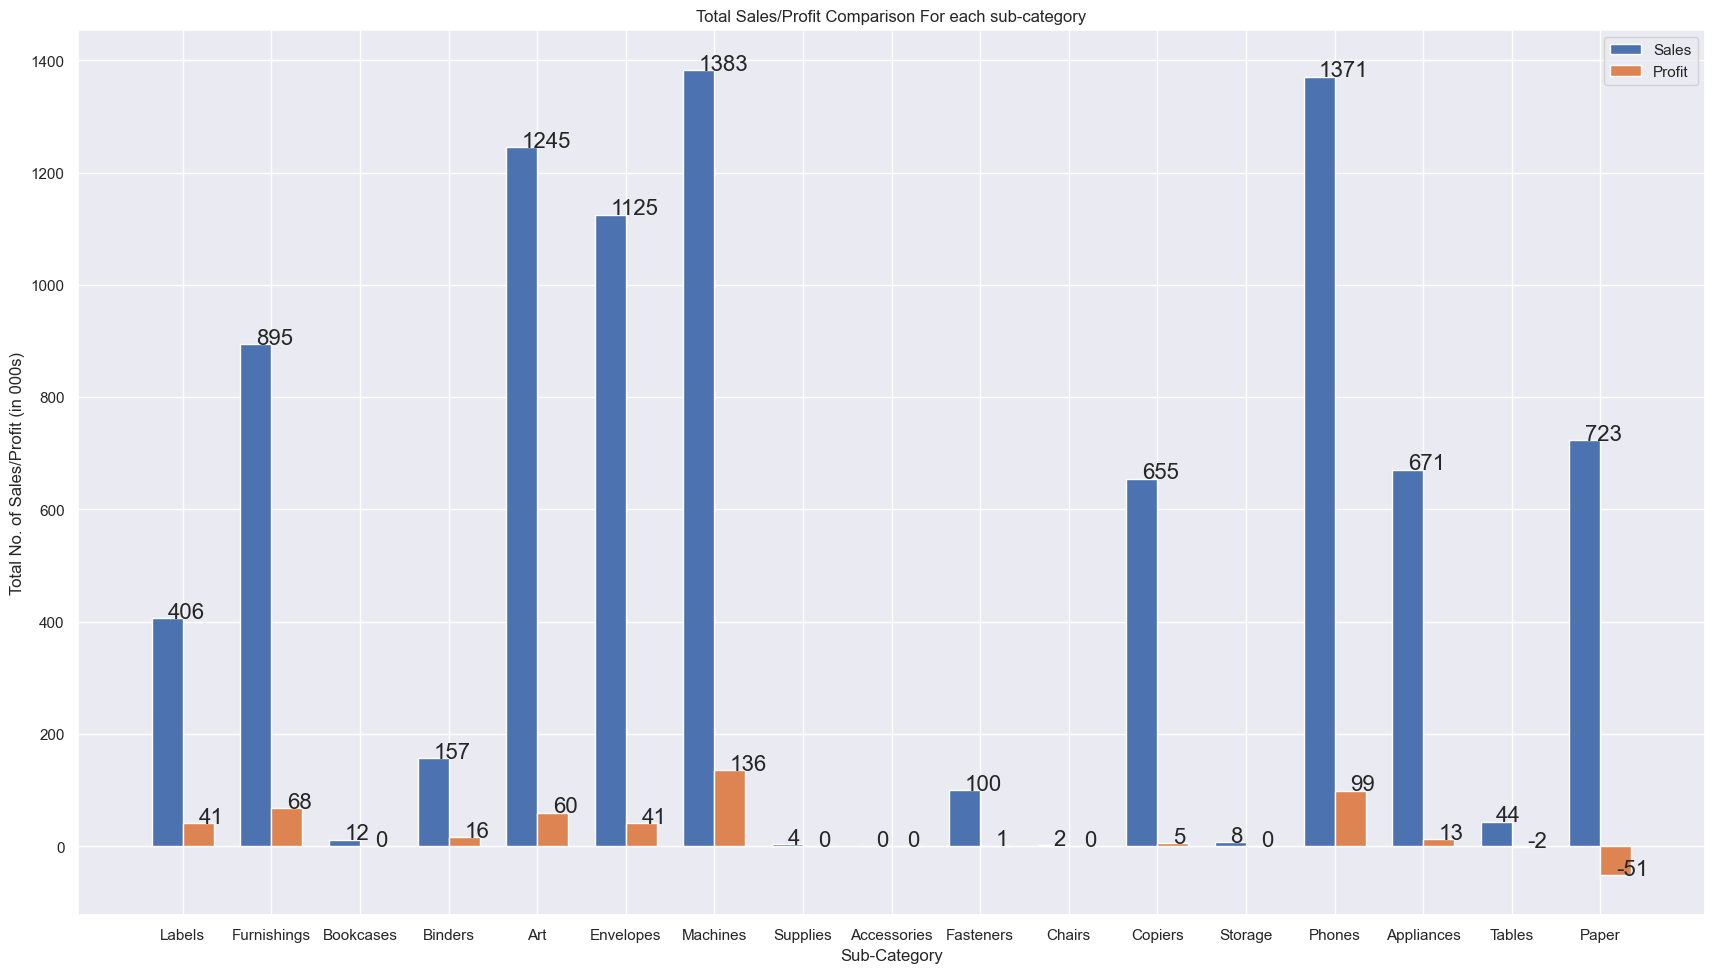

In [65]:
labels = initial_data['Sub-Category'].unique()

x = np.arange(len(labels))  # the label locations
width = .35  # the width of the bars

initial_data['Sales_mn'] = (initial_data['Sales'] / 1000).round(0)
initial_data['Profit_mn'] = (initial_data['Profit'] / 1000).round(0)

initial_data['Sales_mn'] = initial_data['Sales_mn'].astype(np.int64)
initial_data['Profit_mn'] = initial_data['Profit_mn'].astype(np.int64)

n_data_added = initial_data.groupby(['Sub-Category'], as_index=False).agg(
                total_sales = ("Sales_mn", "sum"),
                total_profit = ("Profit_mn","sum")

)

fig, ax = plt.subplots()
Sales_bars = ax.bar(x - width/2, n_data_added['total_sales'], width, label='Sales') # Add color here
Profit_bars = ax.bar(x + width/2, n_data_added['total_profit'], width, label='Profit')

# Add some text for labels, title, configure chart size
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Total No. of Sales/Profit (in 000s)')
ax.set_title('Total Sales/Profit Comparison For each sub-category')
ax.set_xticks(x)
ax.set_xticklabels(labels)
fig.set_size_inches(21, 11.5)
plt.rcParams.update({'font.size': 16})

ax.legend()

for bar in Sales_bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval,yval)
    
for bar in Profit_bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval,yval)

<h5>    1.Summarise your findings from the visual.</h5>
<p> The total sales and profit is compared for each subcategory in the dataset and identified that the Machines, Phones, Envelope and Art sub-categories has maximum sales. 
    
    Profit is observed comparatively high for Machines.
    
    However, for Sub-categories such as Tables and Paper was observed to fall under Loss.

<h5>    2.The reason for selecting the chart type you did</h5>
<p> The bar chart than any other is used to avoid clutter for while comparing each sub-category based on 2 elements and better visualisation.

<h5>    3.Mention the pre-attentive attributes used.(atleast 2)</h5>
<p> Color and Form are the pre-attentive attributes used. 
    
    Color such as Blue for Sales and Orange for Profit was used.
    
    Form attribute with specific width size of the bar was used.

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p> Similarity property and Closure property of gestalt principles were used.

### Question 2
<h4>Determine which State in the Central Region has the highest distribution of profits using box plot.<br><br>
    Write the python code in the below cell to create the appropriate visual(single visual) to perform the above task .
<h4>Answer in markdown cells below the visual <br><br>    

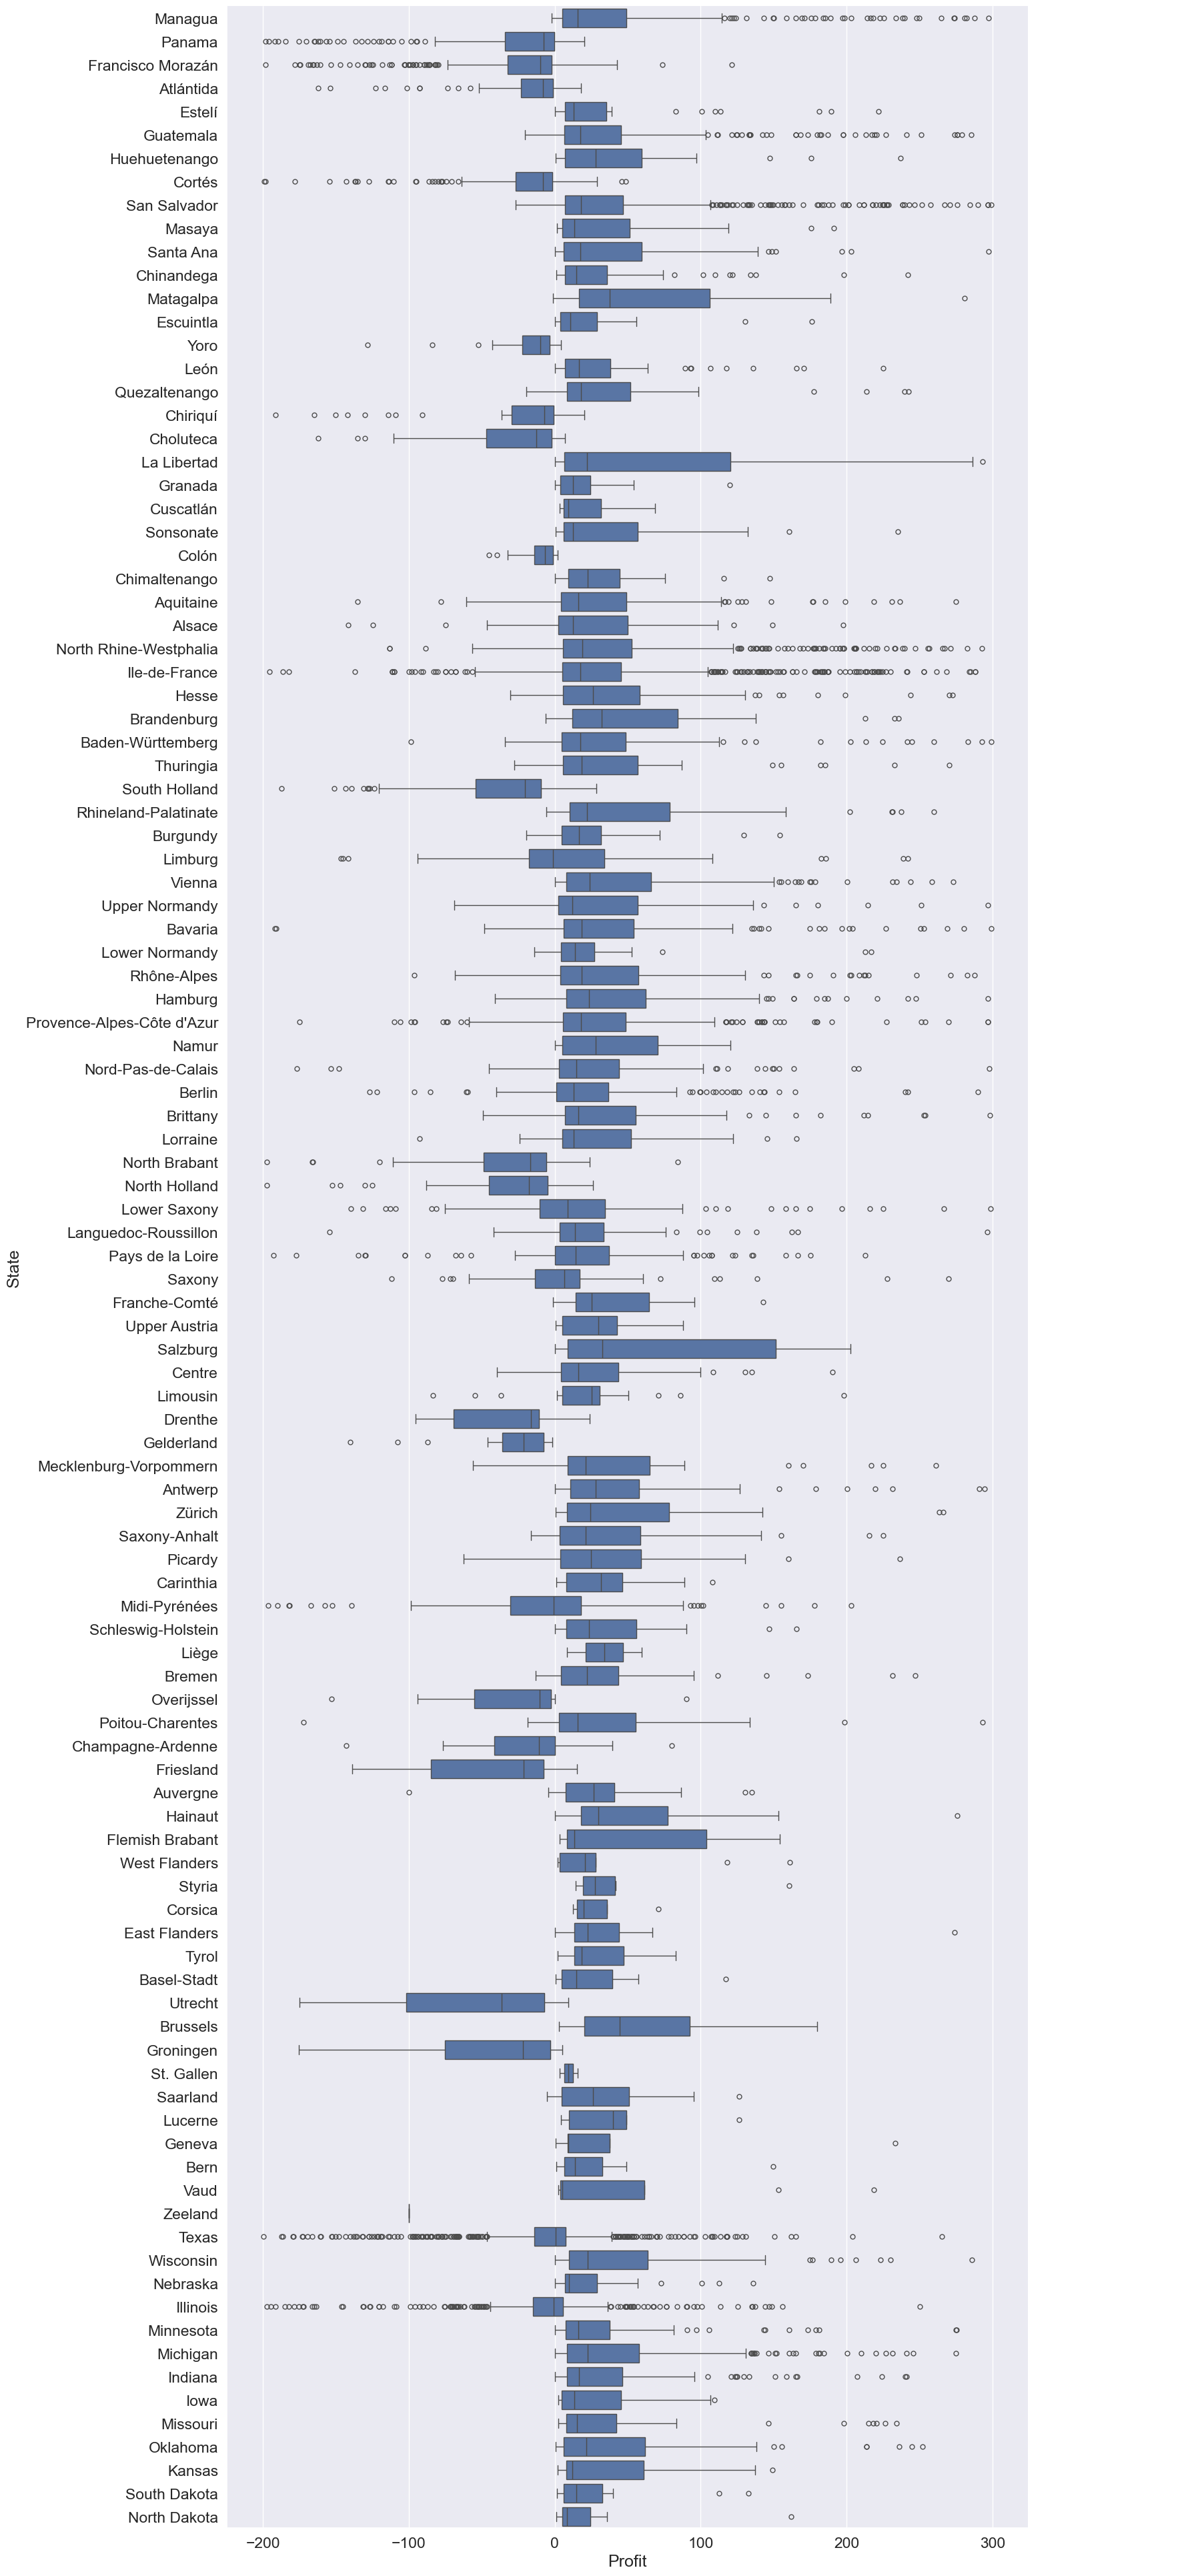

In [66]:
centralRegionData = initial_data[initial_data['Region']=='Central']
modifiedData=centralRegionData[(centralRegionData['Profit'] > -200) & (centralRegionData['Profit'] < 300)]
sns.set(font_scale = 1.5)
p = sns.catplot(kind='box', data=modifiedData, x = 'Profit', y = 'State')
p.fig.set_figwidth(50)
p.fig.set_figheight(50)

<h5>    1.Summarise your findings from the visual.</h5>
<p> From the above chart the distribution of the profit among the provinces of Central region, we can observe that Salzburg is having highest profit when compared to other States in the region. 

<h5>    2.The reason for selecting the chart type you did</h5>

<p> Catplot chart was used since this gives clear visual of Quartile 1, Quartile 2, Quartile 3, Quartile 4, Mean and Median, while other charts such as scatter plot will have more clutter that will be difficult for analysis.

<h5>    3.Mention the pre-attentive attributes used.(atleast 2)</h5>
<p> Color and Form are the pre-attentive attributes used. 
    
    Color such as Hues and intensities are preattentively processed for Profit.
    
    Form attribute of Length, breadth and width was used.

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p>Proximilty Similarity property and Closure property of gestalt principles were used. ---

<h5>    5.How many products are sold at the store,in total?</h5>
<p> -----TBD-----

### Question 3
<h4>Identify which region has more number of orders and in which subcategory.<br><br>
    Write the python code in the below cell to create appropriate(single)visual to perform the above task.
<h4>Answer in markdown cells below the visual <br><br>    

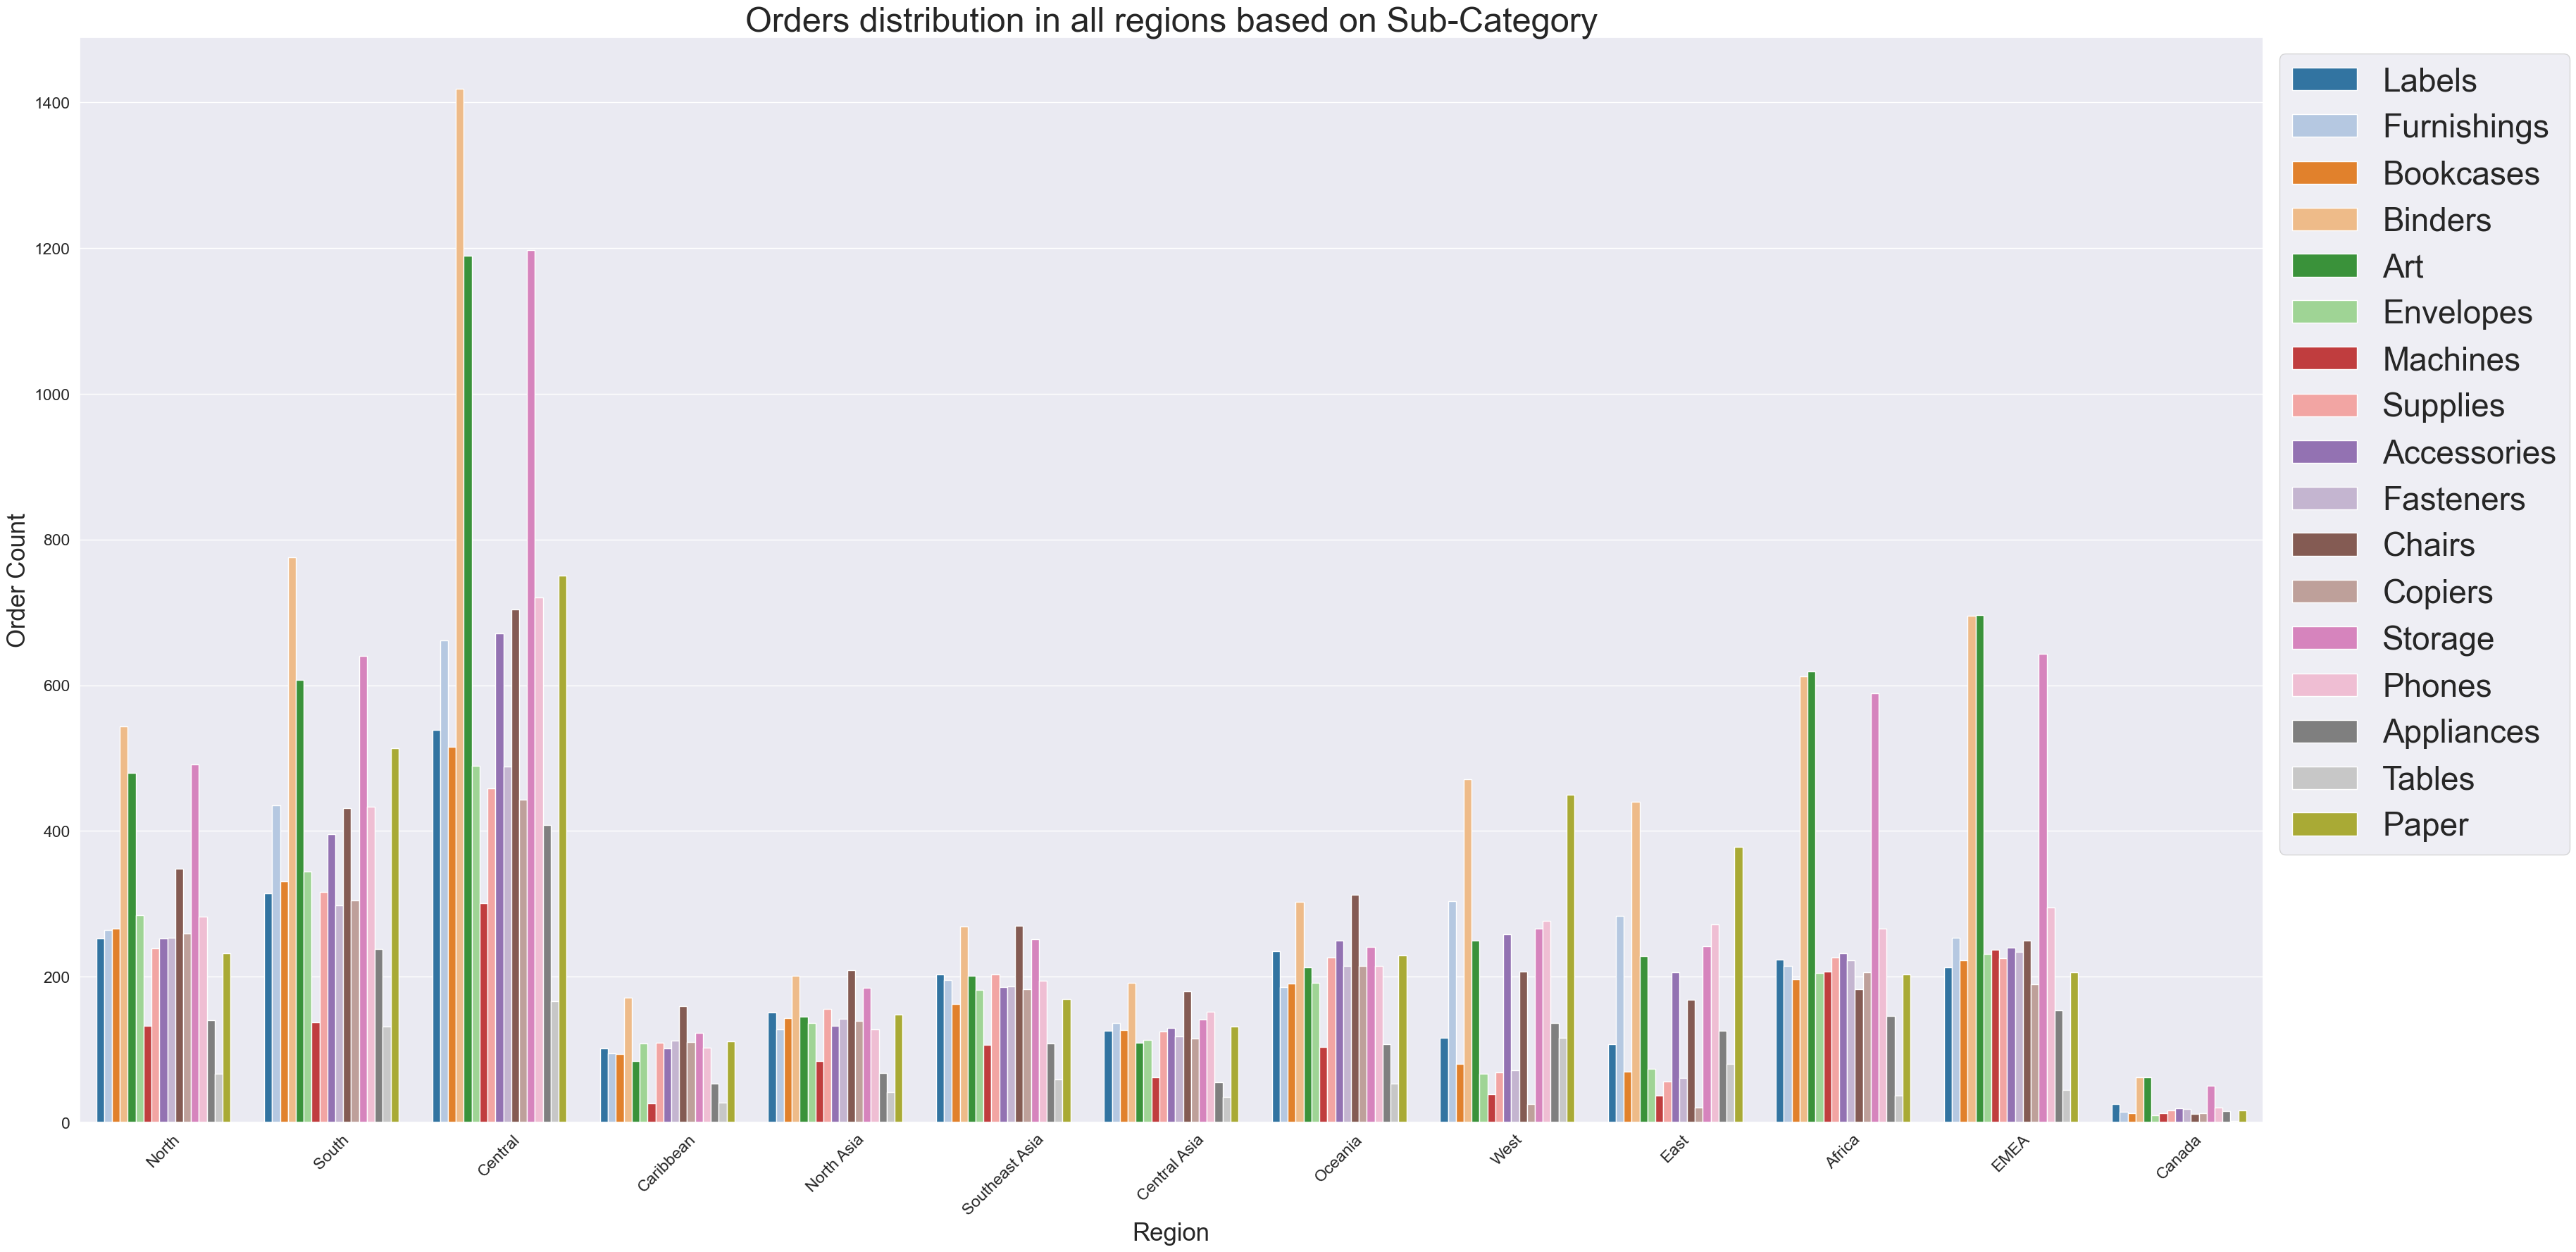

In [67]:
fig, ax1 = plt.subplots(figsize=(40,20))
sns.set(font_scale = 3)
ax = sns.countplot(x="Region", hue = "Sub-Category", data = initial_data, palette= "tab20", ax=ax1)
ax.set_title(label = "Orders distribution in all regions based on Sub-Category", fontsize= 35)
ax.set_xlabel(xlabel = "Region", fontsize = 25)
ax.set_ylabel(ylabel = "Order Count", fontsize = 25)
ax1.xaxis.set_tick_params(rotation=45)
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

<h5>    1.Summarise your findings from the visual.</h5>
<p> From the above Binders sub-category is having more number of orders under Central Region

<h5>    2.The reason for selecting the chart type you did</h5>
<p> As we had to group the sub-category along with Regionwise attribute the bar chart was used to summarize with a clear visual.
    This chart helps to analyse the region with more number of orders.

<h5>    3.Mention the pre-attentive attributes used.(atleast 2)</h5>
<p> Color and Form are the pre-attentive attributes used.

Standard Colors for Order distribution in all regions based on Sub-Category is plotted as legends.

Form attribute such as size of the bar and Spatial grouping was used.

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p> Proximity property and Similarity property of gestalt principles were used.

### Question 4
<h4>In which region do all Product Categories fall beneath the overall average profit?<br><br>
    Write the python code in the below cell to create the appropriate visual(single visual) to perform the above task .
<h4>Answer in markdown cells below the visual <br><br>    

            Region         Category      Profit
0           Africa        Furniture   25.771926
1           Africa  Office Supplies    9.353055
2           Africa       Technology   48.440717
3           Canada        Furniture   62.220000
4           Canada  Office Supplies   28.727545
5           Canada       Technology  111.486462
6        Caribbean        Furniture   16.551755
7        Caribbean  Office Supplies   15.229472
8        Caribbean       Technology   39.676202
9          Central        Furniture   26.662190
10         Central  Office Supplies   17.490588
11         Central       Technology   63.484038
12    Central Asia        Furniture  102.375967
13    Central Asia  Office Supplies   24.396490
14    Central Asia       Technology  122.962908
15            EMEA        Furniture   14.979397
16            EMEA  Office Supplies    4.509976
17            EMEA       Technology   18.185492
18            East        Furniture    5.068496
19            East  Office Supplies   23

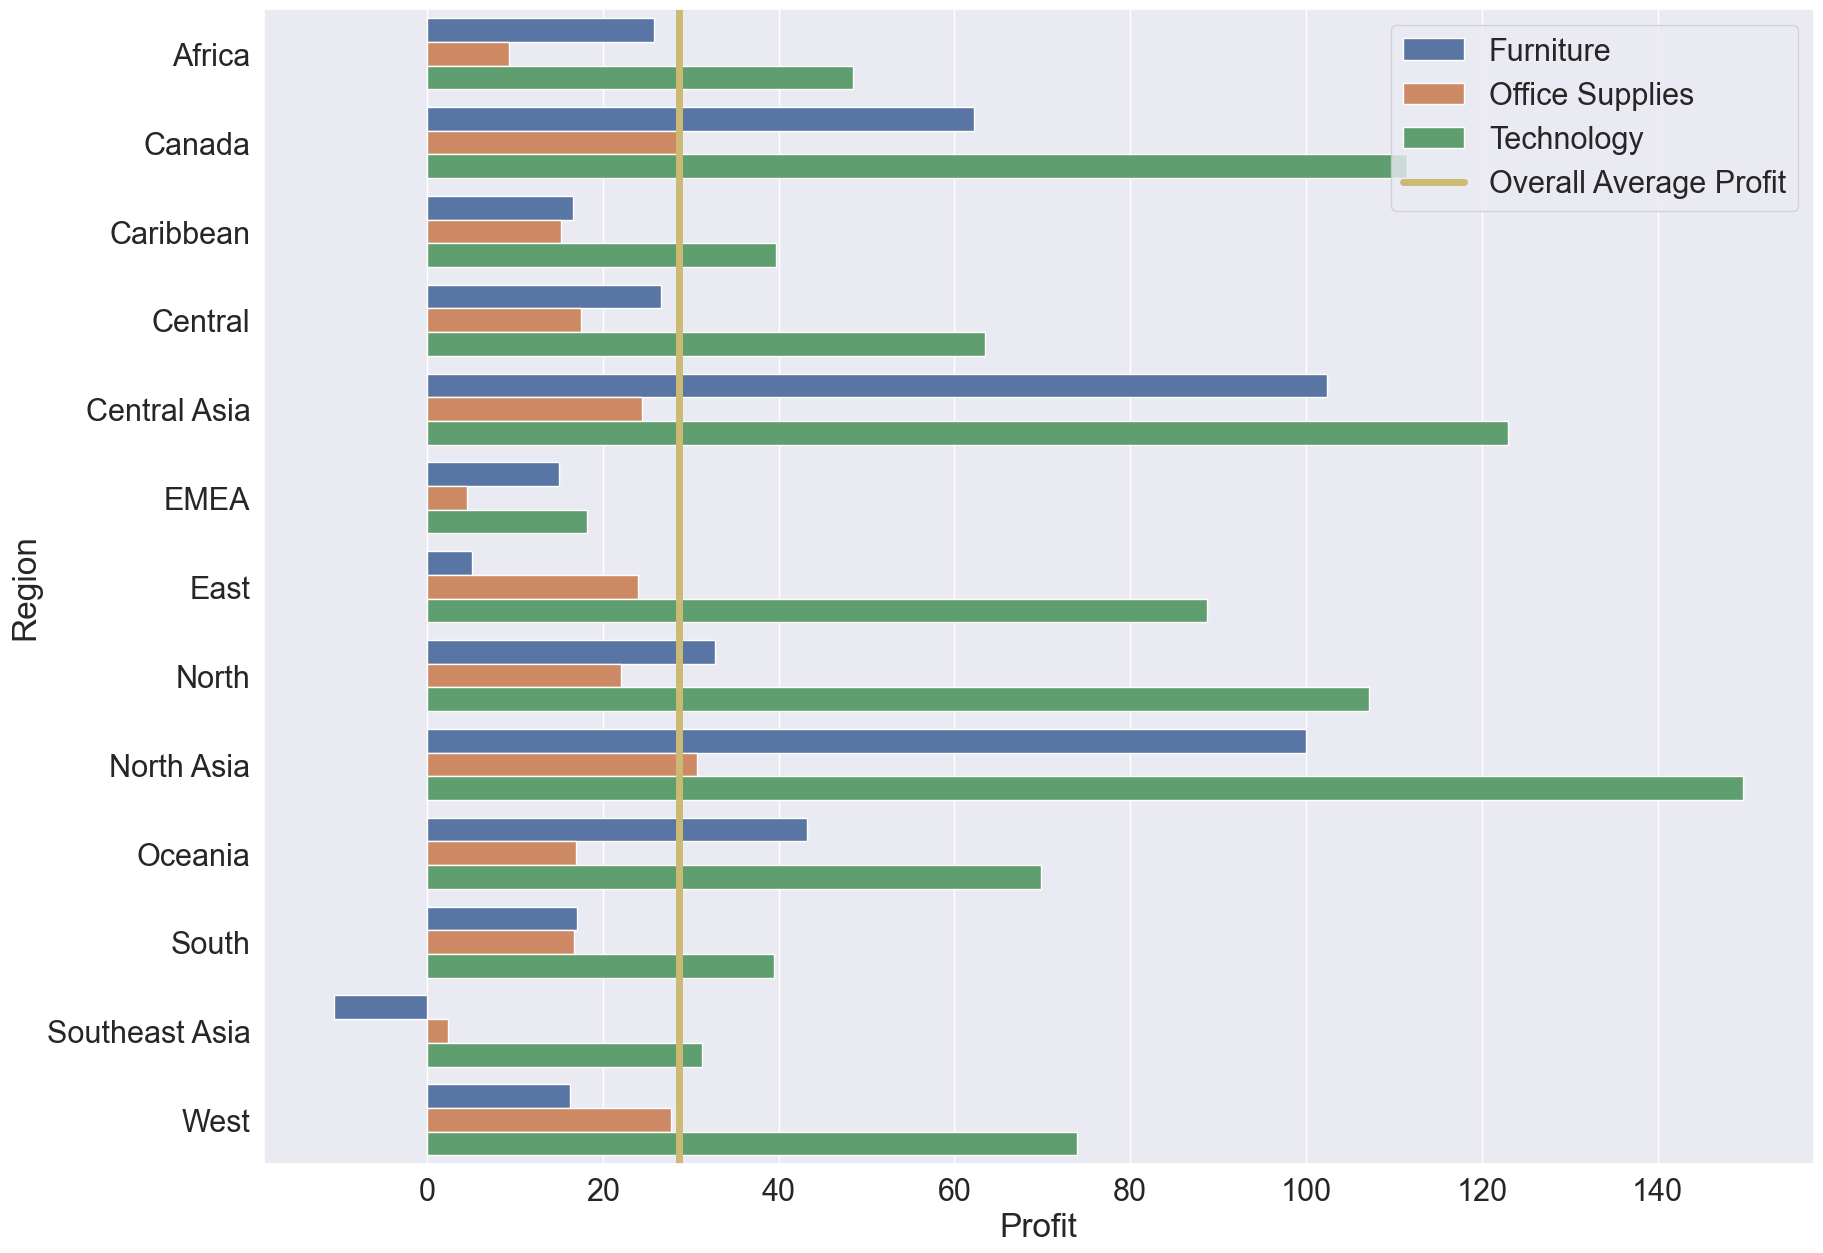

In [68]:
retailTable = initial_data.groupby(['Region','Category'], as_index=False)['Profit'].mean()
print(retailTable)
plt.figure(figsize=(20, 15))
sns.set(font_scale = 2)
sns.barplot(data=retailTable, x='Profit', y='Region', hue='Category')
#plt.vlines(x = 28, ymin = 0, ymax = 13, color = 'yellow', linewidth=3)
plt.axvline(x=initial_data['Profit'].mean(), color='y', label='Overall Average Profit', linewidth=5)
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper right')

plt.show()

In [69]:
initial_data['Profit'].mean()

np.float64(28.61098247767596)

<h5>    1.Summarise your findings from the visual.</h5>
<p> From the above chart the Product Categories falling beneath the overall average profit mean of 28.610982477675567 is observed.

We can observe that in the Region EMEA All the Product categories are falling behind the Average Profit.

<h5>    2.The reason for selecting the chart type you did </h5>
<p> To determine the Overall Average Profit using the bar chart by ploting legends on upper right serves the purpose of the analysis.
    
    The unique Category is plotted in x axis and Region for each Category with Profit is plotted in the y axis. 
    
    This method of bar chart has helped to visualise the average line marked as overall average profit mean.

<h5>    3.Mention the pre-attentive attributes used.(atleast 2)</h5>
<p> Color and Form are the pre-attentive attributes used.
    
    Colors for Category was used in plotting the legend in all regions based on Profit.
    
    Form attribute such as size of the bar legth, Width and Spatial grouping was used. 

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p> Proximity property and Closure property of gestalt principles were used.

### Question No 5

<h4>Find the customer with the lowest overall profit. What is his/her profit ratio?<br><br>
    Write the python code in the below cell to create the appropriate visual(single visual) to perform the above task.
<h4>Answer in markdown cells below the visual <br><br>   

In [70]:
initial_data['Customer ID'].nunique()

1590

In [71]:
#Grouping the Customer ID and aggregate value of sales to profit ratio
retail = initial_data.groupby(['Customer ID','Customer Name'], as_index=False).agg({'Profit': lambda x: x.sum(),'Sales': lambda x: x.sum()})
retail['Profit Ratio'] = retail['Profit']/retail['Sales']
retail = retail.sort_values('Profit')
retail.reset_index()

,index,Customer ID,Customer Name,Profit,Sales,Profit Ratio
0,352,CS-12505,Cindy Stewart,-6437.36810,11535.24640,-0.558061
1,452,DM-3345,Denise Monton,-5474.61000,4998.42000,-1.095268
2,622,GT-14635,Grant Thornton,-3790.08306,19080.34784,-0.198638
3,920,LF-17185,Luke Foster,-3700.19550,12864.72050,-0.287623
4,1089,MT-8070,Michelle Tran,-2991.61800,6851.92200,-0.436610
...,...,...,...,...,...,...
1585,656,HL-15040,Hunter Lopez,7657.50178,29664.23058,0.258139
1586,150,BE-11335,Bill Eplett,7790.69630,27158.01840,0.286865
1587,1353,SC-20095,Sanjit Chand,8106.21790,25602.61000,0.316617
1588,1243,RB-19360,Raymond Buch,8523.95150,29197.63460,0.291940


In [72]:
#Concatenation of top 4 and bottom 4 value
bottomAndTop4 = pd.concat([retail.head(4), retail.tail(4)], axis=0)
print (bottomAndTop4)

     Customer ID   Customer Name      Profit        Sales  Profit Ratio
352     CS-12505   Cindy Stewart -6437.36810  11535.24640     -0.558061
452      DM-3345   Denise Monton -5474.61000   4998.42000     -1.095268
622     GT-14635  Grant Thornton -3790.08306  19080.34784     -0.198638
920     LF-17185     Luke Foster -3700.19550  12864.72050     -0.287623
150     BE-11335     Bill Eplett  7790.69630  27158.01840      0.286865
1353    SC-20095    Sanjit Chand  8106.21790  25602.61000      0.316617
1243    RB-19360    Raymond Buch  8523.95150  29197.63460      0.291940
1489    TC-20980    Tamara Chand  8787.47490  34218.26900      0.256807


<Axes: xlabel='Profit', ylabel='Customer Name'>

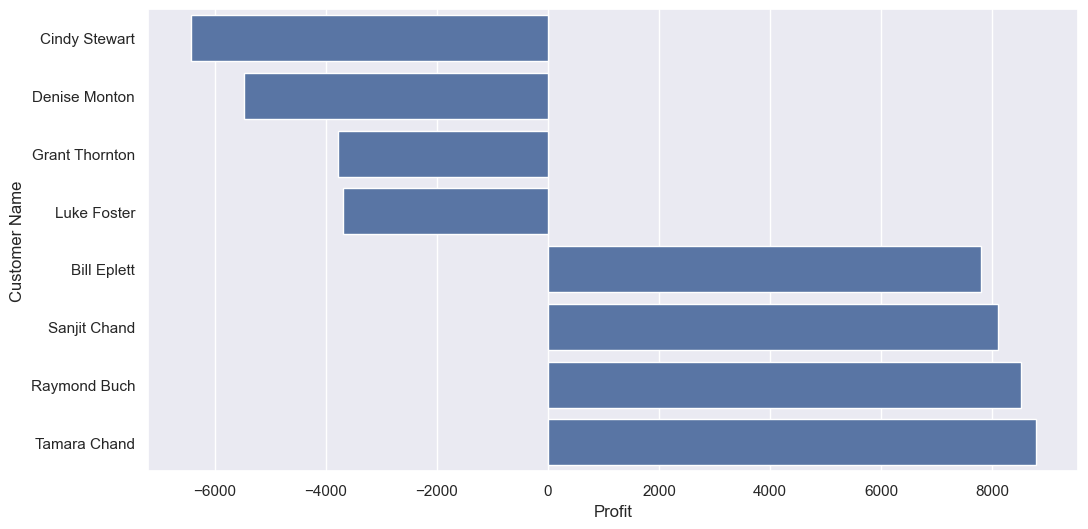

In [73]:
#Plotting the chart based on Customer name
plt.figure(figsize=(12, 6))
sns.set(font_scale = 1)
sns.barplot(x = 'Profit', y = 'Customer Name', data = bottomAndTop4)

<h5>    1.Summarise your findings from the visual.</h5>
<p> To create the appropriate single visual and perform the given task we have grouped the Customer ID and displayed the chart with Customer name to observe the Customers with the lowest overall profit from the resulting visual.
Hence, the customer with lowest profit observed is Cindy Stewart with -6437.36810

<h5>    2.The reason for selecting the chart type you did </h5>
<p> The bar chart compares the profit and customer better by sorting based on ascending order of profit and Calculated columns that is grouped by index.    
Concatenation of top 4 and bottom 4 values to display the sorted Customer names by using head and tail functions was used for more clarity on the visual representation.    

<h5>    3.Mention the pre-attentive attributes used.(atleast 2)</h5>
<p> Color and Form are the pre-attentive attributes used.

Colors for Category was used in plotting the Customers based on profit ratio to Sales.

Form attribute such as the scale and size of the bar legth, width was used. 

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p> Proximity property and Closure property of gestalt principles were used.

 # Group's choice
 
#### Frame 1 (more) question which will help in the EDA(Exploratory Data Analysis) of the given data set and answer the same using the best visual.
 
 1. Write the question in a markdown cell
 2. Below the question,in a coding cell,write the python code to create the visual to answer the question  

<h4> Answer in markdown cells below the visual <br><br>

### Question No: 6

<h4>Find the Category with the highest profit. What is the profit ratio based on discount?<br><br>
    Write the python code in the below cell to create the appropriate visual(single visual) to perform the above task 

<Axes: xlabel='Category', ylabel='Discount'>

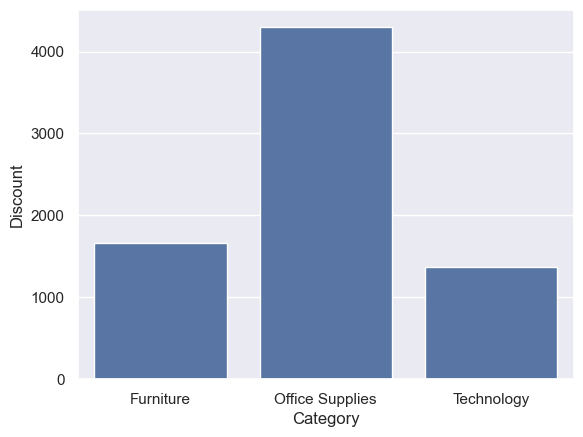

In [74]:
retail = initial_data.groupby(['Category'], as_index=False).agg({'Profit': lambda x: x.sum(),'Discount': lambda x: x.sum(),'Sales': lambda x: x.sum()})
retail['Profit Ratio'] = retail['Profit']/retail['Sales']
retail.head()
sns.set(font_scale = 1)
#rfmTable.info()
#rfmTable.index()
sns.barplot(x = 'Category', y = 'Discount', data = retail)

In [75]:
retail.head()

,Category,Profit,Discount,Sales,Profit Ratio
0,Furniture,285204.72380,1660.030,4.110874e+06,0.069378
1,Office Supplies,518473.83430,4297.190,3.787070e+06,0.136906
2,Technology,663778.73318,1372.508,4.744557e+06,0.139903


<h5>    1.Summarise your findings from the visual.</h5>
<p> From the above chart we analyse the Ccatgory aggregating the profit, discount and sales to calculate profit ratio.
This bar chart is a calculated value from the visual summarizing overall profit and not in the initial data. 
Office Supplies Category displays the highest number of profit and has the highest Discount provided

<h5>    2.The reason for selecting the chart type you did </h5>
<p> Bar chart displays better visual for the above comparison of the category based on discounts and to analyse the profit ratio.
Though the sales and profit for Technology category was higher than Office Supplies category the profit ratio is observed to be lesser than office supplies from the above table.

<h4>    3.Mention the pre-attentive attributes used.(atleast 2)</h4>
<p> Color and Form are the pre-attentive attributes used.

Colors for Category was used in plotting the profit ratio based on discount.

Form attribute such as the scale and size of the bar legth, width was used.

<h5>    4.Mention the gestalt principles used.(atleast 2)</h5>
<p> Proximity property and Closure property of gestalt principles were used.